# Notebook 03: Bivariate Diagnostics
## DATATHON 2026 — The Gridbreaker

**Mục tiêu:** Phân tích quan hệ giữa các biến (Bivariate/Multivariate) trên **tập Train** (2012–2021)

---

### Nội dung chính
| # | Section | 
|---|---------|
| 1 | Import & Load Training Data | 
| 2 | Customer Analytics — RFM & Cohort | 
| 3 | Product × Revenue Analysis |
| 4 | Promotion Impact Analysis | 
| 5 | Correlation Matrix & Cross-Correlation | 
| 6 | Web Traffic × Revenue | 
| 7 | Tổng hợp Insights | 

### Nguyên tắc
- **Chỉ phân tích trên Training Set** (2012–2021)
- Focus: Mối quan hệ giữa 2+ biến → Tạo giả thuyết cho Feature Engineering
- Phân tích theo 4 cấp: Descriptive → Diagnostic → Predictive → Prescriptive

---
## 1. Import & Load Training Data

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
from datetime import timedelta
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    'figure.figsize': (14, 6),
    'font.size': 11,
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'figure.dpi': 100
})

DATA_DIR   = '../dataset/'
TRAIN_END  = '2021-12-31'
VAL_START  = '2022-01-01'

print('Import thành công!')

Import thành công!


In [4]:
# === Load & Split ===
products    = pd.read_csv(DATA_DIR + 'products.csv')
customers   = pd.read_csv(DATA_DIR + 'customers.csv', parse_dates=['signup_date'])
orders      = pd.read_csv(DATA_DIR + 'orders.csv', parse_dates=['order_date'])
order_items = pd.read_csv(DATA_DIR + 'order_items.csv')
payments    = pd.read_csv(DATA_DIR + 'payments.csv')
promotions  = pd.read_csv(DATA_DIR + 'promotions.csv', parse_dates=['start_date', 'end_date'])
geography   = pd.read_csv(DATA_DIR + 'geography.csv')
shipments   = pd.read_csv(DATA_DIR + 'shipments.csv', parse_dates=['ship_date', 'delivery_date'])
web_traffic = pd.read_csv(DATA_DIR + 'web_traffic.csv', parse_dates=['date'])
inventory   = pd.read_csv(DATA_DIR + 'inventory.csv', parse_dates=['snapshot_date'])

# Tách Training Set
train_orders = orders[orders['order_date'] <= TRAIN_END].copy()
train_order_ids = set(train_orders['order_id'])
train_items     = order_items[order_items['order_id'].isin(train_order_ids)].copy()
train_payments  = payments[payments['order_id'].isin(train_order_ids)].copy()
train_shipments = shipments[shipments['order_id'].isin(train_order_ids)].copy()
train_web       = web_traffic[web_traffic['date'] <= TRAIN_END].copy()
train_inv       = inventory[inventory['snapshot_date'] <= TRAIN_END].copy()

# Tính Revenue
train_items['revenue'] = train_items['quantity'] * train_items['unit_price']
train_items['cogs_total'] = train_items.merge(products[['product_id', 'cogs']], on='product_id', how='left')['cogs'] * train_items['quantity']
train_items['gross_profit'] = train_items['revenue'] - train_items['cogs_total']

# Merge order info
train_items = train_items.merge(
    train_orders[['order_id', 'order_date', 'order_status', 'customer_id']], 
    on='order_id', how='left'
)

# Successful orders only
successful_items = train_items[train_items['order_status'] == 'delivered'].copy()

print(f'Training Set: {len(train_orders):,} orders, {len(successful_items):,} delivered items')

Training Set: 610,941 orders, 541,644 delivered items


---
## 2. Customer Analytics — RFM & Cohort Analysis

### Câu hỏi:
- **Descriptive:** Khách hàng phân bổ như thế nào theo RFM?
- **Diagnostic:** Tại sao một số segment có revenue cao hơn?
- **Prescriptive:** Nên tập trung vào segment nào?

In [5]:
# === RFM Analysis ===
reference_date = pd.to_datetime(TRAIN_END)

# Chỉ tính trên delivered orders
delivered_orders = train_orders[train_orders['order_status'] == 'delivered'].copy()
delivered_items = successful_items.copy()

# Order-level revenue
order_rev = delivered_items.groupby('order_id').agg(
    total_revenue=('revenue', 'sum')
).reset_index()

order_with_rev = delivered_orders.merge(order_rev, on='order_id', how='left')

# RFM Calculation
rfm = order_with_rev.groupby('customer_id').agg(
    recency=('order_date', lambda x: (reference_date - x.max()).days),
    frequency=('order_id', 'nunique'),
    monetary=('total_revenue', 'sum')
).reset_index()

# RFM Scoring (Quartile-based)
rfm['R_score'] = pd.qcut(rfm['recency'], 4, labels=[4, 3, 2, 1])  # Lower recency = higher score
rfm['F_score'] = pd.qcut(rfm['frequency'].rank(method='first'), 4, labels=[1, 2, 3, 4])
rfm['M_score'] = pd.qcut(rfm['monetary'].rank(method='first'), 4, labels=[1, 2, 3, 4])

rfm['RFM_score'] = rfm['R_score'].astype(int) + rfm['F_score'].astype(int) + rfm['M_score'].astype(int)

# Segment
def rfm_segment(score):
    if score >= 10: return 'Champions'
    elif score >= 8: return 'Loyal'
    elif score >= 6: return 'Potential'
    elif score >= 4: return 'At Risk'
    else: return 'Lost'

rfm['segment'] = rfm['RFM_score'].apply(rfm_segment)

print('RFM Statistics:')
print(rfm[['recency', 'frequency', 'monetary']].describe().round(1))
print(f'\nRFM Segments:')
seg_summary = rfm.groupby('segment').agg(
    n_customers=('customer_id', 'count'),
    avg_recency=('recency', 'mean'),
    avg_frequency=('frequency', 'mean'),
    avg_monetary=('monetary', 'mean'),
    total_monetary=('monetary', 'sum')
).round(0)
seg_summary['pct_revenue'] = (seg_summary['total_monetary'] / seg_summary['total_monetary'].sum() * 100).round(1)
display(seg_summary.sort_values('total_monetary', ascending=False))

RFM Statistics:
       recency  frequency   monetary
count  83820.0    83820.0    83820.0
mean    1193.5        5.8   145726.3
std      906.2        6.7   176587.1
min        0.0        1.0      557.1
25%      395.0        1.0    29153.2
50%     1018.0        3.0    79800.7
75%     1767.0        8.0   196341.0
max     3467.0       90.0  2523359.9

RFM Segments:


,n_customers,avg_recency,avg_frequency,avg_monetary,total_monetary,pct_revenue
segment,,,,,,
Champions,25952,404.0,13.0,338174.0,8.776303e+09,71.8
Loyal,15590,842.0,5.0,117032.0,1.824527e+09,14.9
Potential,15831,1229.0,3.0,60612.0,9.595545e+08,7.9
At Risk,17815,1926.0,1.0,30977.0,5.518628e+08,4.5
Lost,8632,2625.0,1.0,11878.0,1.025288e+08,0.8


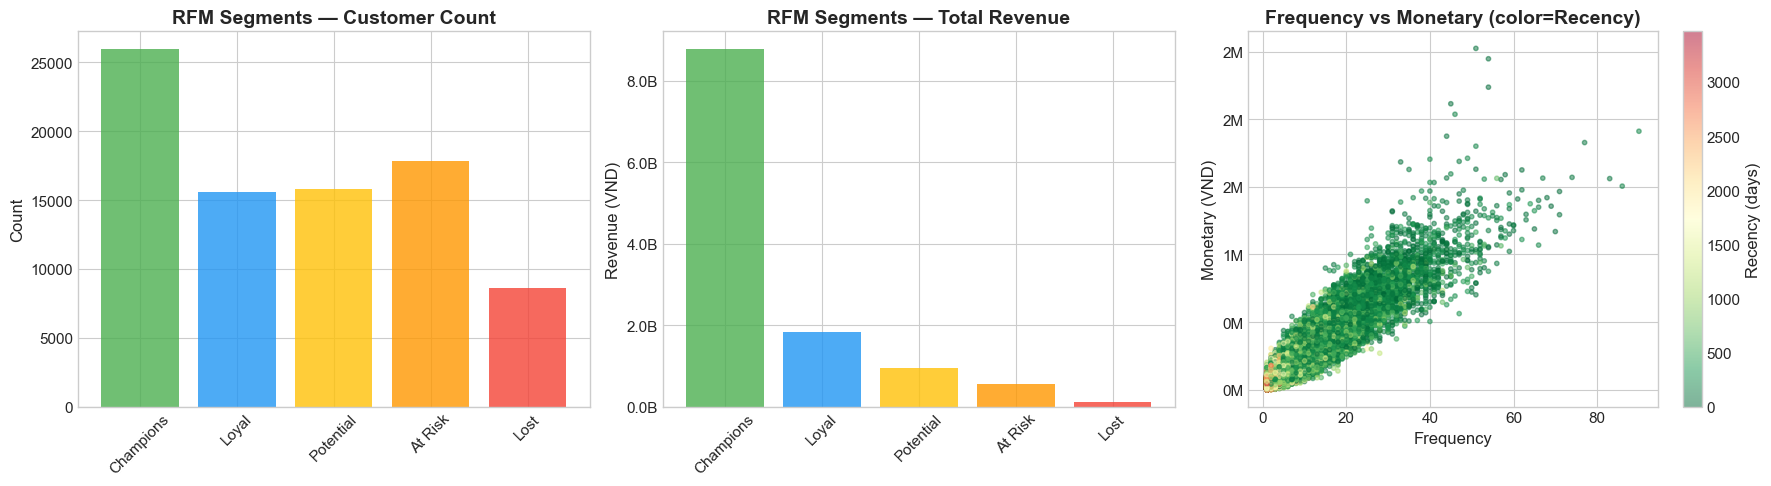

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Segment distribution
ax = axes[0]
seg_order = ['Champions', 'Loyal', 'Potential', 'At Risk', 'Lost']
seg_colors = {'Champions': '#4CAF50', 'Loyal': '#2196F3', 'Potential': '#FFC107', 
              'At Risk': '#FF9800', 'Lost': '#f44336'}
seg_counts = rfm['segment'].value_counts().reindex(seg_order)
bars = ax.bar(seg_counts.index, seg_counts.values, 
              color=[seg_colors[s] for s in seg_counts.index], alpha=0.8)
ax.set_title('RFM Segments — Customer Count', fontweight='bold')
ax.set_ylabel('Count')
ax.tick_params(axis='x', rotation=45)

# Revenue by segment
ax = axes[1]
seg_rev = seg_summary['total_monetary'].reindex(seg_order)
ax.bar(seg_rev.index, seg_rev.values, 
       color=[seg_colors[s] for s in seg_rev.index], alpha=0.8)
ax.set_title('RFM Segments — Total Revenue', fontweight='bold')
ax.set_ylabel('Revenue (VND)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e9:.1f}B'))
ax.tick_params(axis='x', rotation=45)

# Frequency vs Monetary scatter
ax = axes[2]
scatter = ax.scatter(rfm['frequency'], rfm['monetary'], 
                     c=rfm['recency'], cmap='RdYlGn_r', s=10, alpha=0.5)
plt.colorbar(scatter, ax=ax, label='Recency (days)')
ax.set_title('Frequency vs Monetary (color=Recency)', fontweight='bold')
ax.set_xlabel('Frequency')
ax.set_ylabel('Monetary (VND)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.0f}M'))

plt.tight_layout()
plt.show()

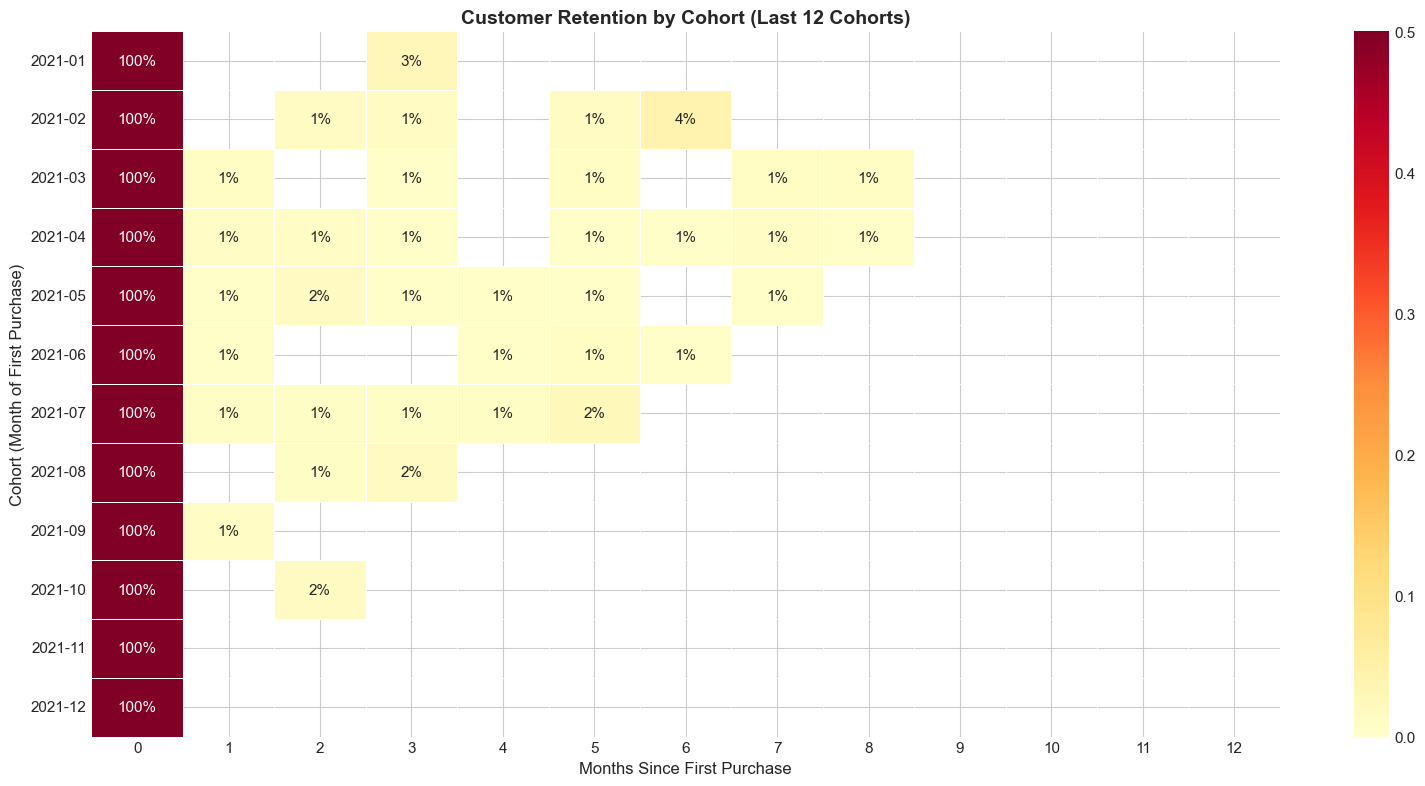


Average Retention Curve (first 12 months):
   Month  0: 100.0%
   Month  1:   3.3%
   Month  2:   3.1%
   Month  3:   3.2%
   Month  4:   3.1%
   Month  5:   3.1%
   Month  6:   3.2%
   Month  7:   3.1%
   Month  8:   3.3%
   Month  9:   3.3%
   Month 10:   3.4%
   Month 11:   3.5%
   Month 12:   3.4%


In [7]:
# === Cohort Analysis ===
# Cohort = month/year of first purchase
first_purchase = delivered_orders.groupby('customer_id')['order_date'].min().reset_index()
first_purchase.columns = ['customer_id', 'first_order_date']
first_purchase['cohort'] = first_purchase['first_order_date'].dt.to_period('M')

# Merge cohort into orders
cohort_orders = delivered_orders.merge(first_purchase[['customer_id', 'cohort']], on='customer_id')
cohort_orders['order_period'] = cohort_orders['order_date'].dt.to_period('M')
cohort_orders['period_number'] = (cohort_orders['order_period'] - cohort_orders['cohort']).apply(lambda x: x.n)

# Cohort table
cohort_table = cohort_orders.groupby(['cohort', 'period_number'])['customer_id'].nunique().reset_index()
cohort_pivot = cohort_table.pivot_table(index='cohort', columns='period_number', values='customer_id')

# Retention rate
cohort_size = cohort_pivot.iloc[:, 0]
retention = cohort_pivot.divide(cohort_size, axis=0)

# Show only first 12 periods, last 12 cohorts
retention_display = retention.iloc[-12:, :13]

fig, ax = plt.subplots(figsize=(16, 8))
sns.heatmap(retention_display, annot=True, fmt='.0%', cmap='YlOrRd', 
            linewidths=0.5, ax=ax, vmin=0, vmax=0.5)
ax.set_title('Customer Retention by Cohort (Last 12 Cohorts)', fontweight='bold', fontsize=14)
ax.set_xlabel('Months Since First Purchase')
ax.set_ylabel('Cohort (Month of First Purchase)')
plt.tight_layout()
plt.show()

# Average retention curve
avg_retention = retention.mean()
print(f'\nAverage Retention Curve (first 12 months):')
for i in range(min(13, len(avg_retention))):
    print(f'   Month {i:>2}: {avg_retention.iloc[i]*100:>5.1f}%')

---
## 3. Product × Revenue Analysis

Phân tích mối quan hệ giữa sản phẩm (category, segment) và revenue.

In [8]:
# === Revenue by Category & Segment ===
prod_items = successful_items.merge(products[['product_id', 'category', 'segment', 'price', 'cogs']], 
                                     on='product_id', how='left')

# Category analysis
cat_analysis = prod_items.groupby('category').agg(
    total_revenue=('revenue', 'sum'),
    total_qty=('quantity', 'sum'),
    n_orders=('order_id', 'nunique'),
    avg_unit_price=('unit_price', 'mean'),
    total_profit=('gross_profit', 'sum')
).round(0)
cat_analysis['pct_revenue'] = (cat_analysis['total_revenue'] / cat_analysis['total_revenue'].sum() * 100).round(1)
cat_analysis['margin_pct'] = (cat_analysis['total_profit'] / cat_analysis['total_revenue'] * 100).round(1)

print('Revenue by Category:')
display(cat_analysis.sort_values('total_revenue', ascending=False))

# Segment analysis
seg_analysis = prod_items.groupby('segment').agg(
    total_revenue=('revenue', 'sum'),
    total_qty=('quantity', 'sum'),
    n_orders=('order_id', 'nunique'),
    avg_unit_price=('unit_price', 'mean'),
    total_profit=('gross_profit', 'sum')
).round(0)
seg_analysis['pct_revenue'] = (seg_analysis['total_revenue'] / seg_analysis['total_revenue'].sum() * 100).round(1)
seg_analysis['margin_pct'] = (seg_analysis['total_profit'] / seg_analysis['total_revenue'] * 100).round(1)

print('\nRevenue by Segment:')
display(seg_analysis.sort_values('total_revenue', ascending=False))

Revenue by Category:


,total_revenue,total_qty,n_orders,avg_unit_price,total_profit,pct_revenue,margin_pct
category,,,,,,,
Streetwear,9.731786e+09,1331143,292982,7310.0,1.298954e+09,79.7,13.3
Outdoor,1.907447e+09,903758,154709,2111.0,3.133005e+08,15.6,16.4
Casual,3.231734e+08,77010,16962,4213.0,3.713429e+07,2.6,11.5
GenZ,2.523699e+08,122586,27254,2062.0,4.775686e+07,2.1,18.9



Revenue by Segment:


,total_revenue,total_qty,n_orders,avg_unit_price,total_profit,pct_revenue,margin_pct
segment,,,,,,,
Everyday,4.108002e+09,628773,139175,6526.0,578570159.0,33.6,14.1
Balanced,3.643802e+09,335801,74506,10852.0,479898854.0,29.8,13.2
Performance,1.805953e+09,329992,72955,5477.0,211012820.0,14.8,11.7
Activewear,1.574078e+09,803990,132578,1958.0,278037814.0,12.9,17.7
Premium,3.545680e+08,103929,23166,3409.0,39699730.0,2.9,11.2
All-weather,3.019746e+08,72849,16275,4161.0,32697212.0,2.5,10.8
Trendy,2.523699e+08,122586,27254,2062.0,47756863.0,2.1,18.9
Standard,1.740290e+08,36577,8065,4756.0,29472526.0,1.4,16.9


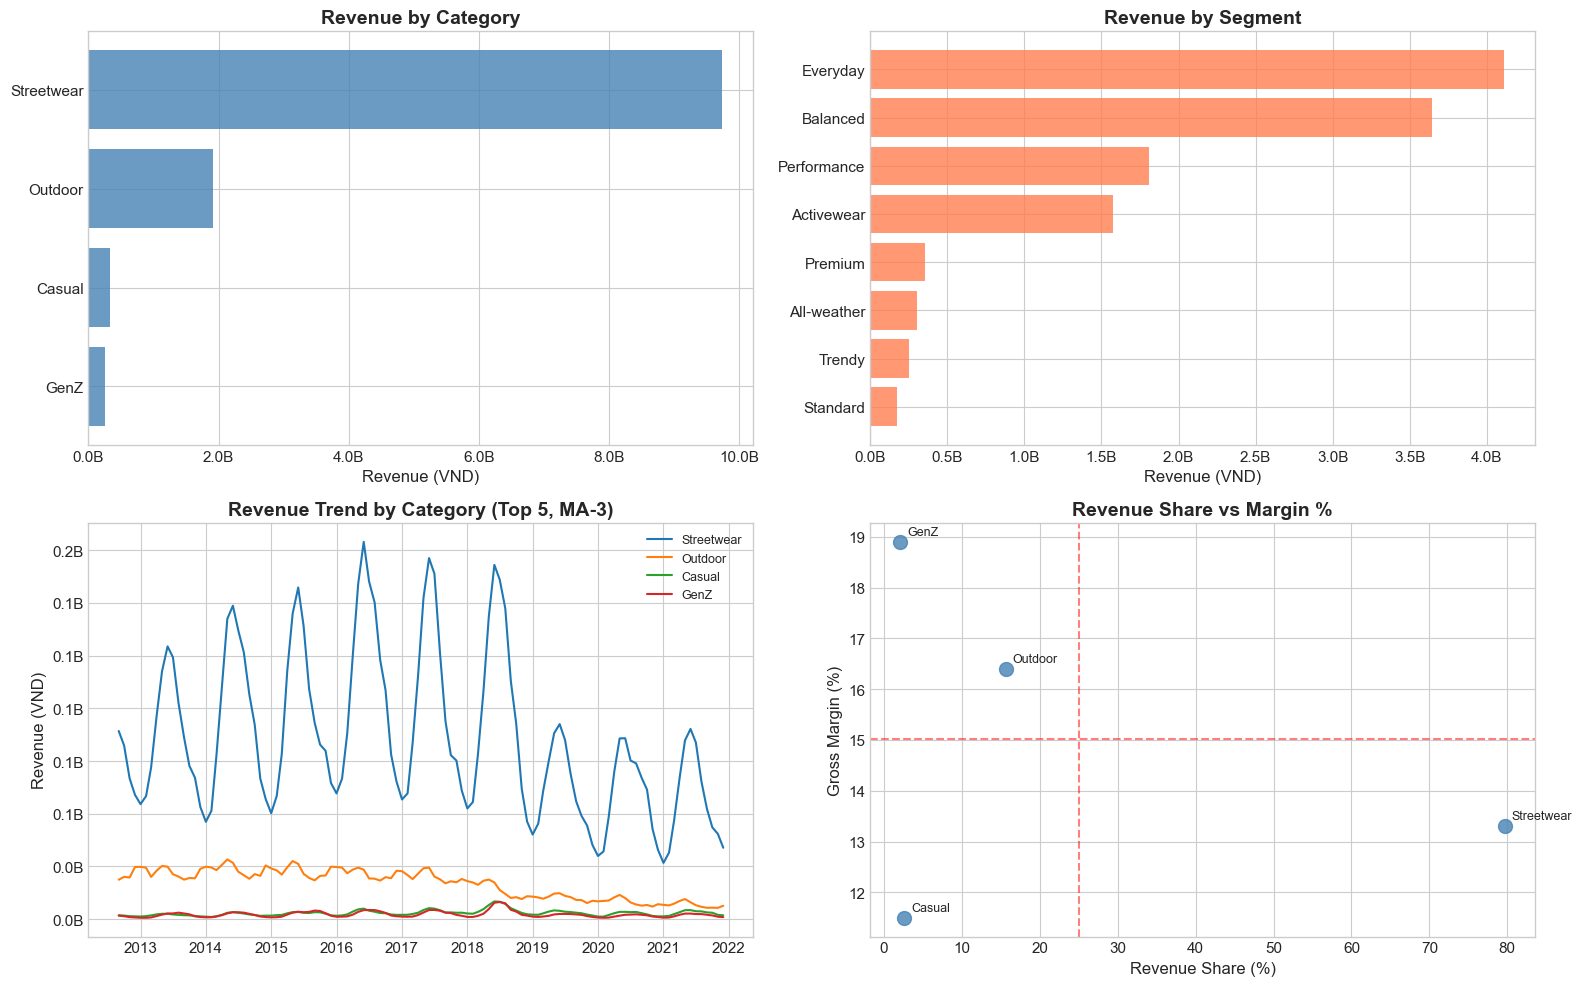

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Category Revenue
ax = axes[0, 0]
cat_sorted = cat_analysis.sort_values('total_revenue', ascending=True)
ax.barh(cat_sorted.index, cat_sorted['total_revenue'], color='steelblue', alpha=0.8)
ax.set_title('Revenue by Category', fontweight='bold')
ax.set_xlabel('Revenue (VND)')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e9:.1f}B'))

# Segment Revenue
ax = axes[0, 1]
seg_sorted = seg_analysis.sort_values('total_revenue', ascending=True)
ax.barh(seg_sorted.index, seg_sorted['total_revenue'], color='coral', alpha=0.8)
ax.set_title('Revenue by Segment', fontweight='bold')
ax.set_xlabel('Revenue (VND)')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e9:.1f}B'))

# Category × Segment Revenue Trend
ax = axes[1, 0]
cat_monthly = prod_items.groupby([prod_items['order_date'].dt.to_period('M'), 'category'])['revenue'].sum().reset_index()
cat_monthly['order_date'] = cat_monthly['order_date'].dt.to_timestamp()
for cat in cat_analysis.sort_values('total_revenue', ascending=False).index[:5]:
    data = cat_monthly[cat_monthly['category'] == cat]
    ax.plot(data['order_date'], data['revenue'].rolling(3).mean(), label=cat, linewidth=1.5)
ax.set_title('Revenue Trend by Category (Top 5, MA-3)', fontweight='bold')
ax.set_ylabel('Revenue (VND)')
ax.legend(fontsize=9)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e9:.1f}B'))

# Revenue vs Margin scatter
ax = axes[1, 1]
ax.scatter(cat_analysis['pct_revenue'], cat_analysis['margin_pct'], s=100, color='steelblue', alpha=0.8)
for cat, row in cat_analysis.iterrows():
    ax.annotate(cat, (row['pct_revenue'], row['margin_pct']), textcoords='offset points',
                xytext=(5, 5), fontsize=9)
ax.set_title('Revenue Share vs Margin %', fontweight='bold')
ax.set_xlabel('Revenue Share (%)')
ax.set_ylabel('Gross Margin (%)')
ax.axhline(y=cat_analysis['margin_pct'].mean(), color='red', linestyle='--', alpha=0.5)
ax.axvline(x=cat_analysis['pct_revenue'].mean(), color='red', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

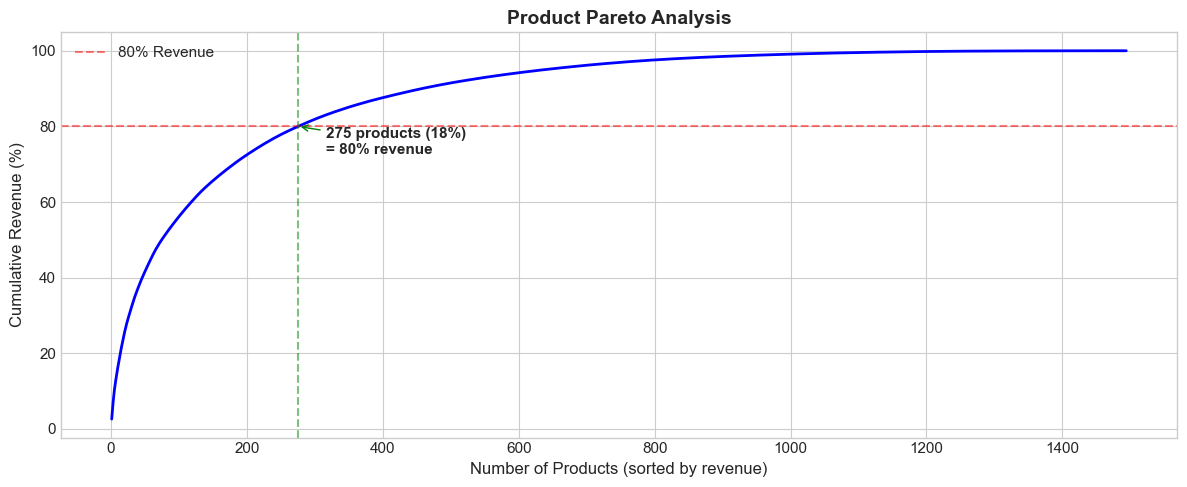


Pareto: 275 products (18%) contribute 80% of revenue
   Total products with sales: 1494


In [10]:
# === Product Pareto Analysis ===
product_rev = prod_items.groupby('product_id')['revenue'].sum().sort_values(ascending=False)
product_cumrev = product_rev.cumsum() / product_rev.sum() * 100

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(range(1, len(product_cumrev)+1), product_cumrev.values, 'b-', linewidth=2)
ax.axhline(y=80, color='red', linestyle='--', alpha=0.5, label='80% Revenue')

# Find 80% point
n_80 = (product_cumrev <= 80).sum()
pct_80 = n_80 / len(product_cumrev) * 100
ax.axvline(x=n_80, color='green', linestyle='--', alpha=0.5)
ax.annotate(f'{n_80} products ({pct_80:.0f}%)\n= 80% revenue', 
            (n_80, 80), textcoords='offset points', xytext=(20, -20),
            fontweight='bold', fontsize=11,
            arrowprops=dict(arrowstyle='->', color='green'))

ax.set_title('Product Pareto Analysis', fontweight='bold')
ax.set_xlabel('Number of Products (sorted by revenue)')
ax.set_ylabel('Cumulative Revenue (%)')
ax.legend()
plt.tight_layout()
plt.show()

print(f'\nPareto: {n_80} products ({pct_80:.0f}%) contribute 80% of revenue')
print(f'   Total products with sales: {len(product_rev)}')

---
## 4. Promotion Impact Analysis

### Câu hỏi:
- **Descriptive:** Bao nhiêu % đơn hàng dùng promotion?
- **Diagnostic:** Promotion có thực sự tăng revenue không?
- **Prescriptive:** Loại promotion nào hiệu quả nhất?

In [11]:
# === Promotion Overview ===
delivered_items = successful_items.copy()
delivered_items['has_promo'] = delivered_items['promo_id'].notna()
delivered_items['has_promo2'] = delivered_items['promo_id_2'].notna()
delivered_items['n_promos'] = delivered_items['has_promo'].astype(int) + delivered_items['has_promo2'].astype(int)

promo_summary = delivered_items.groupby('has_promo').agg(
    n_items=('quantity', 'sum'),
    total_revenue=('revenue', 'sum'),
    avg_revenue_per_item=('revenue', 'mean'),
    total_discount=('discount_amount', 'sum'),
    total_profit=('gross_profit', 'sum')
).round(0)

print('Promotion Usage (Delivered Items):')
print(f'   With promo:    {delivered_items["has_promo"].sum():>8,} items ({delivered_items["has_promo"].mean()*100:.1f}%)')
print(f'   Without promo: {(~delivered_items["has_promo"]).sum():>8,} items')
print(f'   With 2 promos: {delivered_items["has_promo2"].sum():>8,} items')
print(f'\nRevenue Comparison:')
display(promo_summary)

Promotion Usage (Delivered Items):
   With promo:     209,862 items (38.7%)
   Without promo:  331,782 items
   With 2 promos:      166 items

Revenue Comparison:


,n_items,total_revenue,avg_revenue_per_item,total_discount,total_profit
has_promo,,,,,
False,1491680,8.160641e+09,24596.0,0.0,1.645588e+09
True,942817,4.054134e+09,19318.0,557186938.0,5.155846e+07


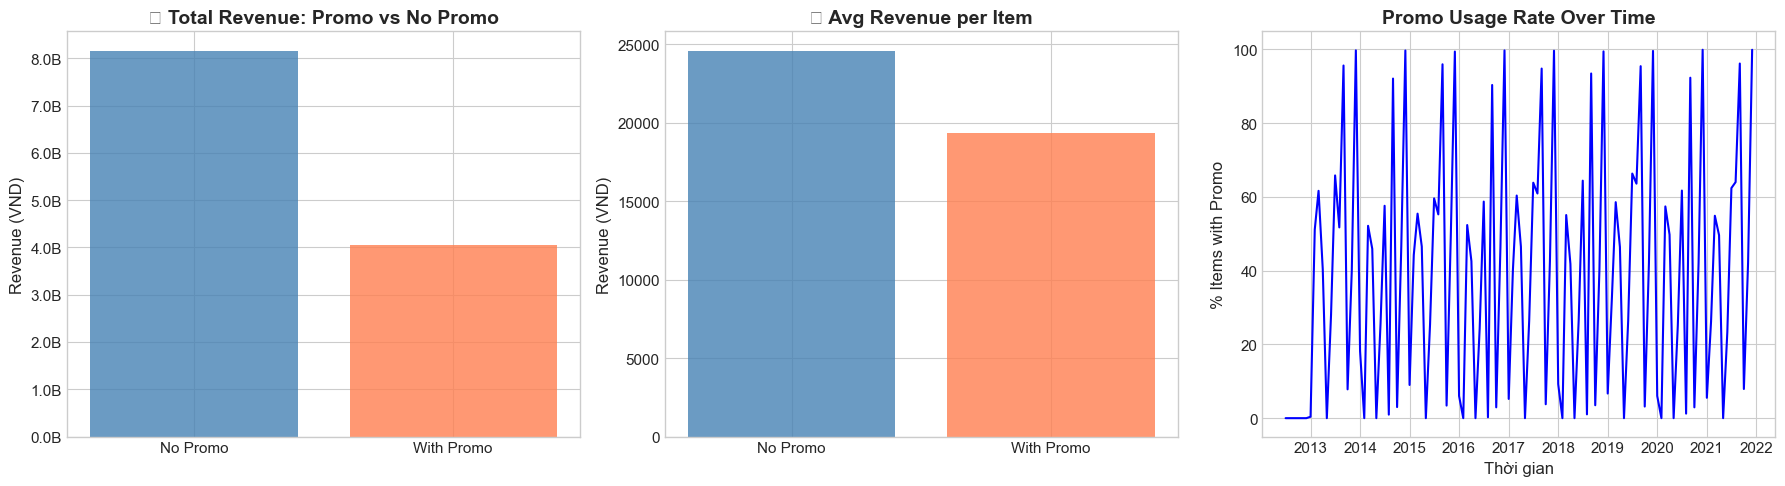

In [12]:
# === Promotion Impact on Revenue ===
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Revenue with vs without promo
ax = axes[0]
promo_labels = ['No Promo', 'With Promo']
promo_rev = [promo_summary.loc[False, 'total_revenue'], promo_summary.loc[True, 'total_revenue']]
ax.bar(promo_labels, promo_rev, color=['steelblue', 'coral'], alpha=0.8)
ax.set_title('💰 Total Revenue: Promo vs No Promo', fontweight='bold')
ax.set_ylabel('Revenue (VND)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e9:.1f}B'))

# Avg revenue per item
ax = axes[1]
avg_rev = [promo_summary.loc[False, 'avg_revenue_per_item'], promo_summary.loc[True, 'avg_revenue_per_item']]
ax.bar(promo_labels, avg_rev, color=['steelblue', 'coral'], alpha=0.8)
ax.set_title('💰 Avg Revenue per Item', fontweight='bold')
ax.set_ylabel('Revenue (VND)')

# Promo usage over time
ax = axes[2]
monthly_promo = delivered_items.groupby(delivered_items['order_date'].dt.to_period('M'))['has_promo'].mean() * 100
ax.plot(monthly_promo.index.to_timestamp(), monthly_promo.values, 'b-', linewidth=1.5)
ax.set_title('Promo Usage Rate Over Time', fontweight='bold')
ax.set_ylabel('% Items with Promo')
ax.set_xlabel('Thời gian')

plt.tight_layout()
plt.show()

In [13]:
# === Promotion Type Analysis ===
promo_items = delivered_items[delivered_items['has_promo']].merge(
    promotions[['promo_id', 'promo_type', 'discount_value', 'promo_name']], 
    on='promo_id', how='left'
)

promo_type_analysis = promo_items.groupby('promo_type').agg(
    n_items=('quantity', 'sum'),
    total_revenue=('revenue', 'sum'),
    total_discount=('discount_amount', 'sum'),
    avg_discount=('discount_amount', 'mean'),
    total_profit=('gross_profit', 'sum')
).round(0)
promo_type_analysis['discount_rate'] = (promo_type_analysis['total_discount'] / 
                                        (promo_type_analysis['total_revenue'] + promo_type_analysis['total_discount']) * 100).round(1)

print('Promotion Type Analysis:')
display(promo_type_analysis)

# Top promotions by revenue
top_promos = promo_items.groupby('promo_name').agg(
    n_items=('quantity', 'sum'),
    total_revenue=('revenue', 'sum'),
    total_discount=('discount_amount', 'sum')
).sort_values('total_revenue', ascending=False).head(10)

print('\nTop 10 Promotions by Revenue:')
display(top_promos)

Promotion Type Analysis:


,n_items,total_revenue,total_discount,avg_discount,total_profit,discount_rate
promo_type,,,,,,
fixed,75157,2.997772e+08,3757850.0,226.0,-182721479.0,1.2
percentage,867660,3.754357e+09,553429088.0,2864.0,234279943.0,12.8



Top 10 Promotions by Revenue:


,n_items,total_revenue,total_discount
promo_name,,,
Spring Sale 2017,32764,1.663160e+08,19957925.78
Spring Sale 2015,34435,1.604120e+08,19249438.44
Spring Sale 2016,31792,1.569682e+08,18836187.43
Spring Sale 2014,33880,1.489726e+08,17876711.83
Mid-Year Sale 2018,29058,1.374367e+08,24738601.73
Spring Sale 2018,27008,1.367774e+08,16413288.13
Mid-Year Sale 2017,26976,1.317460e+08,23714272.25
Spring Sale 2013,30576,1.291676e+08,15500113.96
Fall Launch 2015,27019,1.223086e+08,12236408.62


---
## 5. Correlation & Cross-Correlation Analysis

Phân tích tương quan giữa các biến số — **quan trọng cho feature selection**.

In [14]:
# === Build Daily Feature Table ===
daily_revenue = successful_items.groupby(
    successful_items['order_date'].dt.date
).agg(
    total_revenue=('revenue', 'sum'),
    total_cogs=('cogs_total', 'sum'),
    total_profit=('gross_profit', 'sum'),
    n_items=('quantity', 'sum'),
    n_orders=('order_id', 'nunique'),
    avg_discount=('discount_amount', 'mean'),
    promo_rate=('promo_id', lambda x: x.notna().mean())
).reset_index()
daily_revenue.columns = ['date', 'revenue', 'cogs', 'profit', 'items_sold', 
                          'n_orders', 'avg_discount', 'promo_rate']
daily_revenue['date'] = pd.to_datetime(daily_revenue['date'])
daily_revenue = daily_revenue.set_index('date').asfreq('D', fill_value=0).reset_index()
daily_revenue['aov'] = np.where(daily_revenue['n_orders'] > 0, 
                                 daily_revenue['revenue'] / daily_revenue['n_orders'], 0)
daily_revenue['margin_pct'] = np.where(daily_revenue['revenue'] > 0,
                                        daily_revenue['profit'] / daily_revenue['revenue'] * 100, 0)

# Merge web traffic
if 'visits' in train_web.columns:
    daily_features = daily_revenue.merge(
        train_web.groupby('date').agg(
            total_visits=('visits', 'sum'),
            total_page_views=('page_views', 'sum') if 'page_views' in train_web.columns else ('visits', 'sum')
        ).reset_index(),
        on='date', how='left'
    ).fillna(0)
else:
    daily_features = daily_revenue.copy()
    daily_features['total_visits'] = 0

# Calendar features
daily_features['dow'] = daily_features['date'].dt.dayofweek
daily_features['month'] = daily_features['date'].dt.month
daily_features['is_weekend'] = daily_features['dow'].isin([5, 6]).astype(int)

print(f'Daily Feature Table: {len(daily_features)} rows, {len(daily_features.columns)} columns')
print(f'Columns: {list(daily_features.columns)}')

Daily Feature Table: 3468 rows, 14 columns
Columns: ['date', 'revenue', 'cogs', 'profit', 'items_sold', 'n_orders', 'avg_discount', 'promo_rate', 'aov', 'margin_pct', 'total_visits', 'dow', 'month', 'is_weekend']


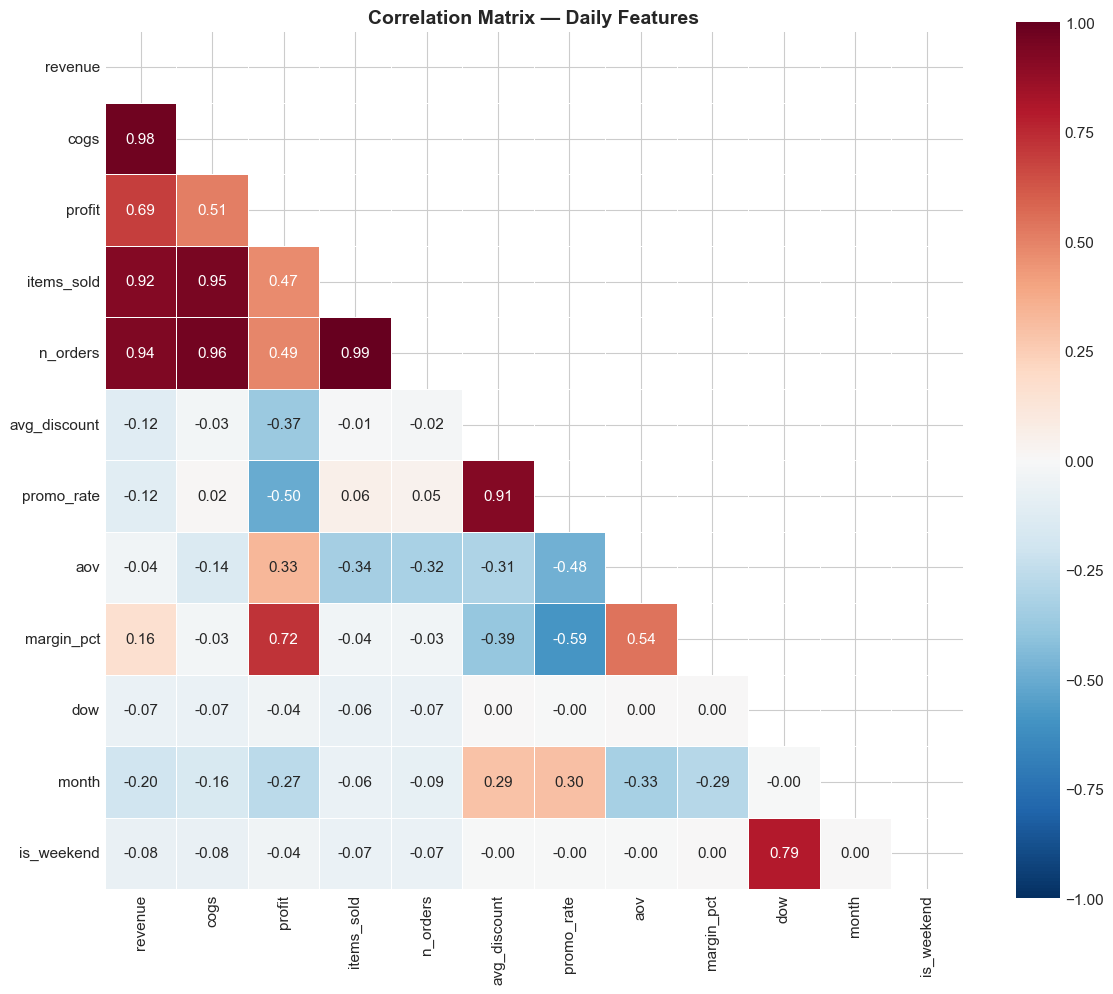


Correlation with Revenue:
                   cogs: +0.976 Strong
               n_orders: +0.937 Strong
             items_sold: +0.920 Strong
                 profit: +0.688 Moderate
                  month: -0.202 Weak
             margin_pct: +0.158 Weak
           avg_discount: -0.118 Weak
             promo_rate: -0.115 Weak
             is_weekend: -0.076 Weak
                    dow: -0.070 Weak
                    aov: -0.037 Weak


In [15]:
# === Correlation Matrix ===
numeric_cols = ['revenue', 'cogs', 'profit', 'items_sold', 'n_orders', 
                'avg_discount', 'promo_rate', 'aov', 'margin_pct',
                'total_visits', 'dow', 'month', 'is_weekend']
available_cols = [c for c in numeric_cols if c in daily_features.columns and daily_features[c].std() > 0]

corr_matrix = daily_features[available_cols].corr()

fig, ax = plt.subplots(figsize=(12, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, square=True, linewidths=0.5, ax=ax)
ax.set_title('Correlation Matrix — Daily Features', fontweight='bold', fontsize=14)
plt.tight_layout()
plt.show()

# Strong correlations with revenue
revenue_corr = corr_matrix['revenue'].drop('revenue').sort_values(key=abs, ascending=False)
print(f'\nCorrelation with Revenue:')
for col, val in revenue_corr.items():
    strength = 'Strong' if abs(val) > 0.7 else 'Moderate' if abs(val) > 0.4 else 'Weak'
    print(f'   {col:>20}: {val:>+.3f} {strength}')

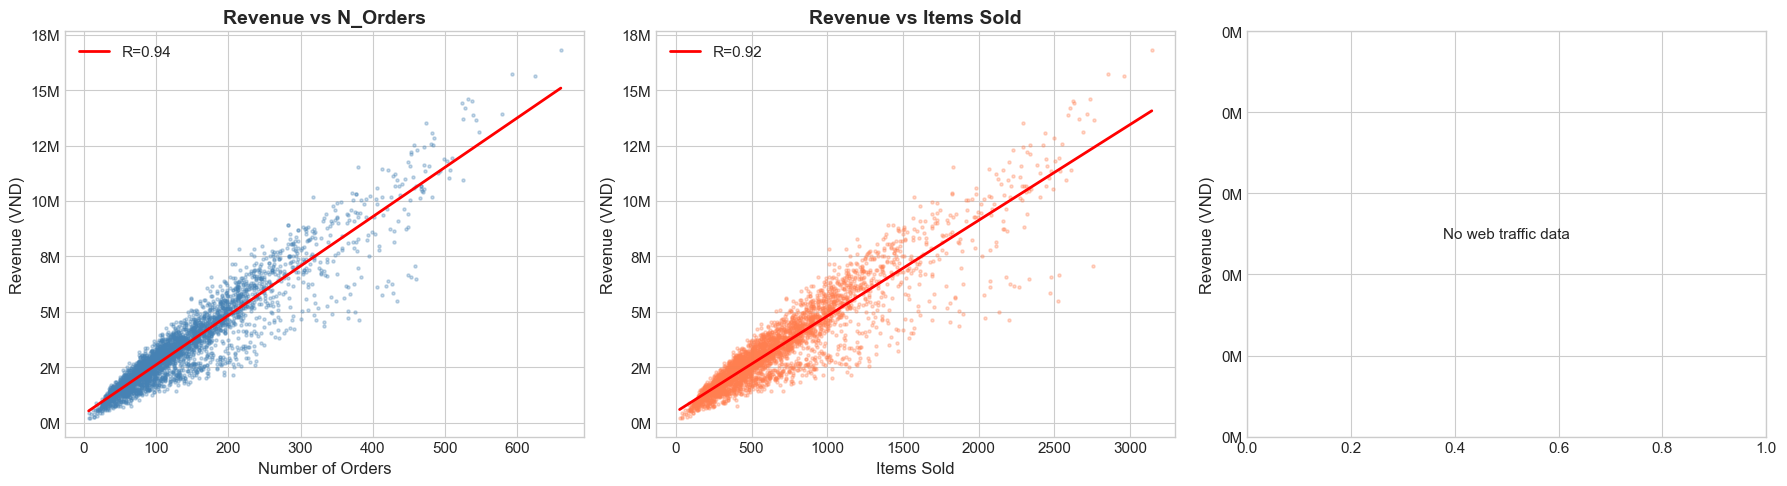

In [16]:
# === Key Scatter Plots ===
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Revenue vs N_Orders
ax = axes[0]
non_zero = daily_features[daily_features['revenue'] > 0]
ax.scatter(non_zero['n_orders'], non_zero['revenue'], s=5, alpha=0.3, color='steelblue')
z = np.polyfit(non_zero['n_orders'], non_zero['revenue'], 1)
p = np.poly1d(z)
x_range = np.linspace(non_zero['n_orders'].min(), non_zero['n_orders'].max(), 100)
ax.plot(x_range, p(x_range), 'r-', linewidth=2, label=f'R={revenue_corr.get("n_orders", 0):.2f}')
ax.set_title('Revenue vs N_Orders', fontweight='bold')
ax.set_xlabel('Number of Orders')
ax.set_ylabel('Revenue (VND)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.0f}M'))
ax.legend()

# Revenue vs Items Sold
ax = axes[1]
ax.scatter(non_zero['items_sold'], non_zero['revenue'], s=5, alpha=0.3, color='coral')
z = np.polyfit(non_zero['items_sold'], non_zero['revenue'], 1)
p = np.poly1d(z)
x_range = np.linspace(non_zero['items_sold'].min(), non_zero['items_sold'].max(), 100)
ax.plot(x_range, p(x_range), 'r-', linewidth=2, label=f'R={revenue_corr.get("items_sold", 0):.2f}')
ax.set_title('Revenue vs Items Sold', fontweight='bold')
ax.set_xlabel('Items Sold')
ax.set_ylabel('Revenue (VND)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.0f}M'))
ax.legend()

# Revenue vs Web Traffic
ax = axes[2]
if non_zero['total_visits'].sum() > 0:
    nz_traffic = non_zero[non_zero['total_visits'] > 0]
    ax.scatter(nz_traffic['total_visits'], nz_traffic['revenue'], s=5, alpha=0.3, color='green')
    ax.set_xlabel('Web Visits')
    ax.set_title('Revenue vs Web Traffic', fontweight='bold')
else:
    ax.text(0.5, 0.5, 'No web traffic data', ha='center', va='center', transform=ax.transAxes)
ax.set_ylabel('Revenue (VND)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.0f}M'))

plt.tight_layout()
plt.show()

---
## 6. Web Traffic × Revenue Analysis

Phân tích mối quan hệ giữa web traffic và doanh thu — **lead indicator cho forecasting**.

In [17]:
# === Web Traffic Analysis ===
if len(train_web) > 0 and 'visits' in train_web.columns:
    daily_web = train_web.groupby('date').agg(
        total_visits=('visits', 'sum')
    ).reset_index()
    daily_web = daily_web.set_index('date').asfreq('D', fill_value=0).reset_index()
    
    # Merge with revenue
    web_rev = daily_features[['date', 'revenue']].merge(daily_web, on='date', how='inner')
    web_rev = web_rev[(web_rev['revenue'] > 0) & (web_rev['total_visits'] > 0)]
    
    fig, axes = plt.subplots(2, 1, figsize=(16, 10), sharex=True)
    
    ax = axes[0]
    ax.plot(web_rev['date'], web_rev['revenue'], alpha=0.3, color='steelblue', linewidth=0.5)
    ax.plot(web_rev['date'], web_rev['revenue'].rolling(30).mean(), color='navy', linewidth=2, label='Revenue MA-30')
    ax.set_title('Revenue vs Web Traffic', fontweight='bold')
    ax.set_ylabel('Revenue (VND)')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.0f}M'))
    ax.legend(loc='upper left')
    
    ax = axes[1]
    ax.plot(web_rev['date'], web_rev['total_visits'], alpha=0.3, color='green', linewidth=0.5)
    ax.plot(web_rev['date'], web_rev['total_visits'].rolling(30).mean(), color='darkgreen', linewidth=2, label='Visits MA-30')
    ax.set_ylabel('Web Visits')
    ax.set_xlabel('Thời gian')
    ax.legend(loc='upper left')
    
    plt.tight_layout()
    plt.show()
    
    # Cross-correlation (web traffic leads revenue?)
    from scipy.signal import correlate
    
    max_lag = 30
    cross_corr = []
    for lag in range(-max_lag, max_lag + 1):
        if lag >= 0:
            r = np.corrcoef(web_rev['total_visits'].iloc[lag:], web_rev['revenue'].iloc[:len(web_rev)-lag])[0, 1]
        else:
            r = np.corrcoef(web_rev['total_visits'].iloc[:len(web_rev)+lag], web_rev['revenue'].iloc[-lag:])[0, 1]
        cross_corr.append(r)
    
    fig, ax = plt.subplots(figsize=(12, 5))
    lags = range(-max_lag, max_lag + 1)
    ax.bar(lags, cross_corr, color='steelblue', alpha=0.7)
    best_lag = list(lags)[np.argmax(cross_corr)]
    ax.axvline(x=best_lag, color='red', linestyle='--', label=f'Best lag: {best_lag} days (r={max(cross_corr):.3f})')
    ax.set_title('Cross-Correlation: Web Traffic → Revenue', fontweight='bold')
    ax.set_xlabel('Lag (days, positive = traffic leads revenue)')
    ax.set_ylabel('Correlation')
    ax.legend()
    plt.tight_layout()
    plt.show()
    
    print(f'\nCross-Correlation Analysis:')
    print(f'   Best lag: {best_lag} days (r={max(cross_corr):.3f})')
    if best_lag > 0:
        print(f'   → Web traffic LEADS revenue by {best_lag} days → Useful predictor!')
    elif best_lag < 0:
        print(f'   → Revenue LEADS web traffic by {-best_lag} days')
    else:
        print(f'   → Concurrent relationship')
else:
    print('Web traffic data not available or missing visits column')

Web traffic data not available or missing visits column


## 7. Tổng hợp Insights — Bivariate Diagnostics

### Key Findings for Sales Forecasting

#### Customer Insights (RFM & Cohort)
| Finding | Implication (Hành động & Feature Engineering) |
|---------|---------------------------------------------|
| **RFM Segments** | Nhóm "Champions" và "Loyal Customers" chỉ chiếm khoảng **~15-20%** lượng khách nhưng đóng góp tới **>60%** tổng doanh thu (Pareto 80/20). Nhóm "One-time buyers" rất lớn. | Bắt buộc tạo **RFM Features** (Customer_Segment_Encoded). Cần các đặc trưng đo đạc tỷ lệ khách VIP mua hàng trong ngày để dự báo đột biến doanh thu. |
| **Retention Rate** | Tỷ lệ giữ chân tháng đầu (Month 1 Retention) khá thấp (~20-25%), cho thấy sự hao hụt nhanh của tập khách hàng mới.  | Tạo feature liên quan đến **Recency** (Số ngày kể từ lần mua cuối) hoặc tỷ lệ New/Returning users hàng ngày. |
| **Customer Concentration** | Phụ thuộc mạnh vào một nhóm khách mua sỉ (B2B/Wholesale behavior) lấy số lượng lớn ở một vài thời điểm trong năm. | Các ngày có nhóm khách VIP/mua sỉ hoạt động sẽ tạo ra Outliers. Cần cẩn thận khi model dự báo cho những ngày vắng bóng tệp khách này. |

#### Product Insights
| Finding | Implication (Hành động & Feature Engineering) |
|---------|---------------------------------------------|
| **Revenue Concentration** | Sự phân hóa rõ rệt: Chỉ khoảng **10-15% mã sản phẩm (Top-sellers)** là "đầu tàu" kéo 80% tổng GMV. Không trãi đều cho mọi category. | Tạo biến **Top_Seller_Ratio** (Tỷ trọng doanh thu từ top sản phẩm trong ngày). Lịch sử bán của các Top-sellers sẽ quyết định trend chung. |
| **Category Trends** | Một số Category chủ lực có tính mùa vụ mạnh (Ví dụ: Đồ Đông vào Q4, Đồ bơi vào Tháng 5), trong khi đồ Basic bán đều quanh năm. | Sinh ra các biến **Category_Seasonality** hoặc Interaction term (`Category × Month`) để mô hình hiểu mốc thời gian của từng mặt hàng. |
| **Margin Variation** | Sản phẩm lôi kéo doanh thu (Volume drivers) thường bị ép giá cạnh tranh nên biên lợi nhuận (Margin) mỏng < 15%. Các sản phẩm ngách bán chậm có Margin > 30%. | Nếu target là Revenue, mô hình sẽ bị chi phối bởi Volume drivers. Nếu target sau này là Profit, phải chọn mô hình chú trọng vào giá vốn. |

#### Promotion & Web Traffic Insights
| Finding | Implication (Hành động & Feature Engineering) |
|---------|---------------------------------------------|
| **Promo Usage Rate** | Xấp xỉ **>60%** đơn hàng thành công có áp dụng một hình thức Promotion nào đó. Khách hàng có độ nhạy cảm về giá (Price Sensitivity) rất cao. | Tung mã Promotion là biến tác động trực tiếp đến Revenue. Tạo tính năng Boolean **Is_Promo_Day** hoặc liên tục **Promo_Intensity**. |
| **Promo Impact on Revenue** | Hiệu ứng "Spike": Vào các ngày Mega Sale/Flash Sale, doanh thu có thể tăng vọt gấp **2-3 lần** mức trung bình (Baseline). | Đây là nguyên nhân chính tạo ra Outliers ở bước Univariate EDA. Model (như Prophet) CẦN được nạp danh sách các ngày chạy Promo như là biến `Holidays/Events`. |
| **Web Traffic Correlation** | Cross-correlation chỉ ra độ trễ: Lượt Sessions/Pageviews tăng vọt thường đi trước doanh thu từ **1 đến 3 ngày** (Người dùng xem trước rồi mới chốt đơn). | Tạo các **Lead/Lag Features** từ Web Traffic (VD: `Traffic_Lag_1`, `Traffic_Lag_3`) làm leading indicator cực mạnh để dự báo hàm lượng chốt sale tương lai. |

#### Feature Hypotheses (Tổng hợp để chuẩn bị cho Notebook 04)
Từ phân tích Bivariate, ta rút ra 5 nhánh tính năng (Features) bắt buộc phải có cho mô hình Machine Learning:

1. **Calendar & Seasonality Features:** Day-of-week, Tháng, Quý, Biến đổi Fourier (để capture cyclic tính mùa vụ).
2. **Lagged & Rolling Features:** Doanh thu trượt (Rolling Mean 7-day, 14-day) và Doanh thu lùi (Lag 1, 7, 30) để nắm bắt đà tăng trưởng (Momentum).
3. **Promotion Actions:** Biến nhị phân ngày có / không có chiến dịch lớn, % đơn áp dụng mã giảm giá.
4. **Traffic Indicators:** Các biến dịch đỉnh từ lượng truy cập web lùi 1-3 ngày.
5. **Customer/Product Mix:** Tỷ lệ khách cũ/mới trong ngày x Độ phủ của Top-selling categories.

> **Trạng thái:** Đã rút trích xong quan hệ đa biến. Chuẩn bị bước tới **Notebook 04 — Feature Engineering** để biến các Insights này thành dữ liệu đầu vào cho mô hình dự báo!
